# Xarray-Spatial Reproject: Reprojection and mosaic merge

Satellite imagery and elevation models rarely arrive in the coordinate system you need. A DEM might be in geographic degrees (EPSG:4326) while your analysis needs meters (UTM). Or you have tiles from two different sensors that need to line up in one grid. `xrspatial.reproject` handles both problems: it warps a raster into a new CRS using a fast approximate transform, and `merge` stitches multiple rasters into a single mosaic with configurable overlap handling.

### What you'll build

1. Create a synthetic terrain raster in geographic coordinates (EPSG:4326)
2. Reproject the DEM from geographic to Web Mercator (EPSG:3857) using `reproject`
3. Compare resampling methods: nearest, bilinear, and cubic
4. Split the terrain into two tiles and merge them back with `merge`
5. Test overlap strategies: first, last, and mean
6. Merge rasters that start in different CRS projections

![Reproject preview](images/reproject_preview.png)

[Data](#Data) · [Reproject to Web Mercator](#Reproject-to-Web-Mercator) · [Resampling methods](#Resampling-methods) · [Merge tiles](#Merge-tiles) · [Overlap strategies](#Overlap-strategies) · [Cross-CRS merge](#Cross-CRS-merge)

Standard imports plus xrspatial. `pyproj` is required for reprojection and gets imported internally.

In [1]:
%matplotlib inline
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import xrspatial
from xrspatial.reproject import reproject, merge

## Data

We generate a 256x256 terrain raster using `generate_terrain` and place it in EPSG:4326 (latitude/longitude) coordinates centered near the equator. The coordinate range spans 10 degrees on each side, roughly 1100 km across.

In [2]:
H, W = 256, 256
canvas = xr.DataArray(np.zeros((H, W)), dims=['y', 'x'])
terrain = xrspatial.generate_terrain(canvas, x_range=(0, 500), y_range=(0, 500), seed=42)

# Reassign coordinates to geographic (EPSG:4326)
terrain = terrain.assign_coords(
    y=np.linspace(10, -10, H),   # north-up
    x=np.linspace(-10, 10, W),
)
terrain.attrs['crs'] = 'EPSG:4326'
terrain.name = 'elevation'

print(f"Shape: {terrain.shape}")
print(f"X range: {float(terrain.x.min()):.1f} to {float(terrain.x.max()):.1f} degrees")
print(f"Y range: {float(terrain.y.min()):.1f} to {float(terrain.y.max()):.1f} degrees")
print(f"Elevation range: {float(terrain.min()):.0f} to {float(terrain.max()):.0f} m")

Shape: (256, 256)
X range: -10.0 to 10.0 degrees
Y range: -10.0 to 10.0 degrees
Elevation range: 1952 to 2014 m


The raw elevation in geographic coordinates. Note the axes are in degrees.

Text(0, 0.5, 'Latitude (degrees)')

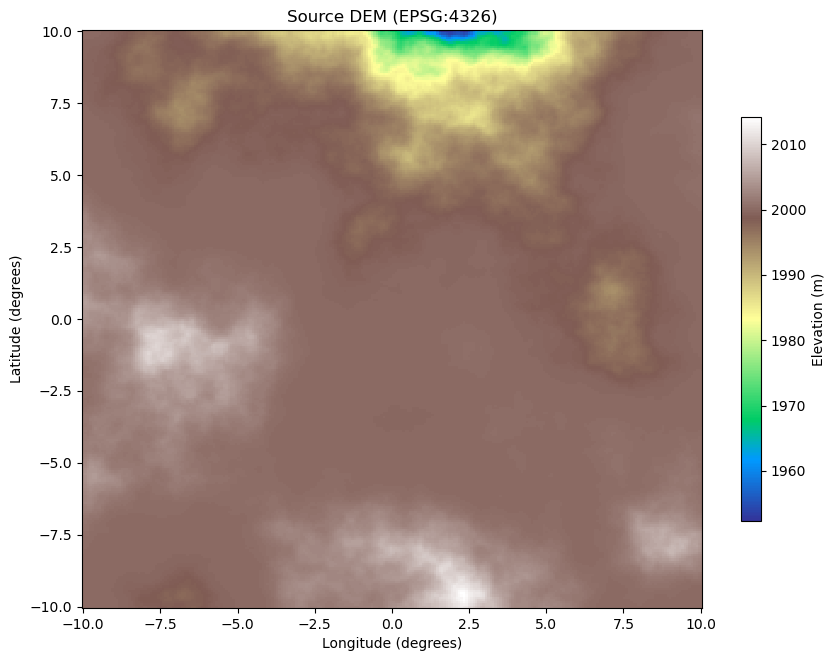

In [3]:
fig, ax = plt.subplots(figsize=(10, 7.5))
terrain.plot.imshow(ax=ax, cmap='terrain', add_colorbar=True,
                    cbar_kwargs={'label': 'Elevation (m)', 'shrink': 0.7})
ax.set_title('Source DEM (EPSG:4326)')
ax.set_xlabel('Longitude (degrees)')
ax.set_ylabel('Latitude (degrees)')

## Reproject to Web Mercator

[Web Mercator](https://en.wikipedia.org/wiki/Web_Mercator_projection) (EPSG:3857) is the projection used by most web mapping platforms. It works in meters rather than degrees, so distance and area calculations make more sense near the equator. `reproject` builds an output grid in the target CRS, then for each output pixel it traces back to the source to sample the value. An approximate transform makes this fast: instead of calling pyproj for every pixel, it evaluates a coarse control grid and interpolates between the exact points.

The plot below shows the same terrain, now with axes in meters.

Output shape: (258, 256)
X range: -1,113,195 to 1,113,195 m
Y range: -1,118,958 to 1,124,895 m


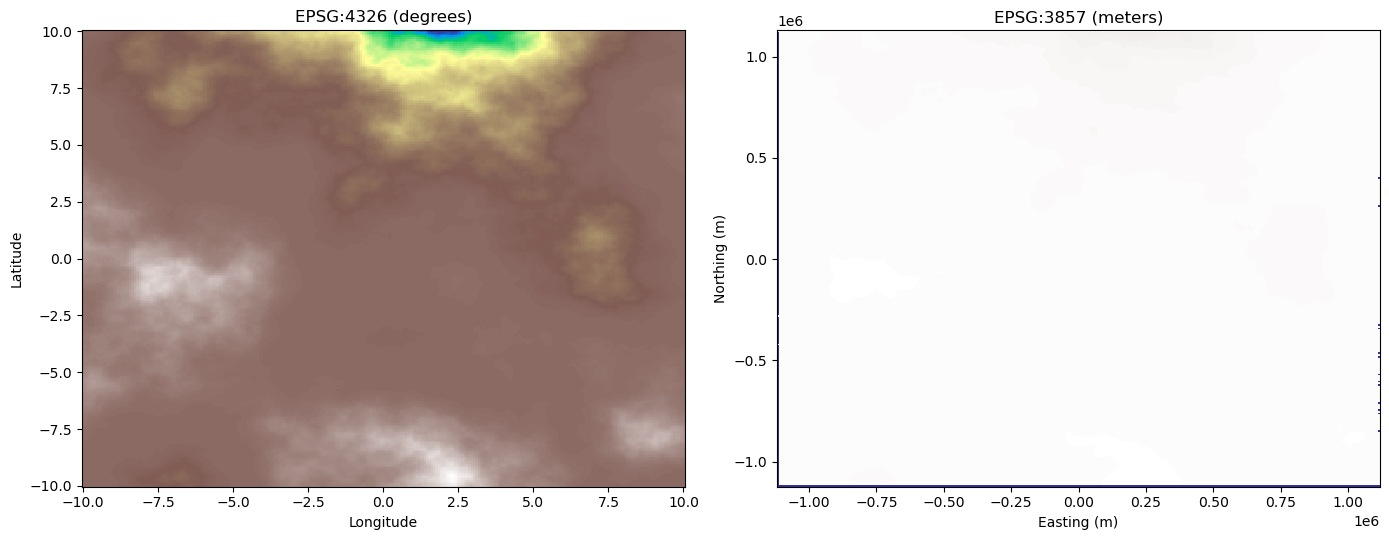

In [4]:
terrain_3857 = reproject(terrain, 'EPSG:3857')

print(f"Output shape: {terrain_3857.shape}")
print(f"X range: {float(terrain_3857.x.min()):,.0f} to {float(terrain_3857.x.max()):,.0f} m")
print(f"Y range: {float(terrain_3857.y.min()):,.0f} to {float(terrain_3857.y.max()):,.0f} m")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

terrain.plot.imshow(ax=axes[0], cmap='terrain', add_colorbar=False)
axes[0].set_title('EPSG:4326 (degrees)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

terrain_3857.plot.imshow(ax=axes[1], cmap='terrain', add_colorbar=False)
axes[1].set_title('EPSG:3857 (meters)')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')

plt.tight_layout()

The terrain features look the same, but the axis units changed from degrees to meters. The shape may differ slightly because the pixel size in the target CRS is estimated from the source resolution.

You can also call `reproject` through the accessor: `terrain.xrs.reproject('EPSG:3857')`.

<div class="alert alert-block alert-warning">
<b>Web Mercator distorts area.</b> EPSG:3857 stretches features at high latitudes. Near the equator (like our test data) the distortion is minimal, but at 60 degrees latitude a pixel covers roughly 4x the ground area it claims. For area-sensitive analysis, use an equal-area projection like Albers (EPSG:5070) instead.
</div>

## Resampling methods

When output pixels don't align exactly with source pixels, the resampler decides how to fill them:

- **nearest**: picks the closest source pixel. Fast, preserves exact values. Good for categorical data (land cover, classification).
- **bilinear**: weighted average of the 4 nearest source pixels. Smooth, the default for continuous data.
- **cubic**: weighted average of 16 neighbors. Smoother still, but can overshoot (ringing near sharp edges).

We reproject to a deliberately coarse grid (50x50) to exaggerate the differences.

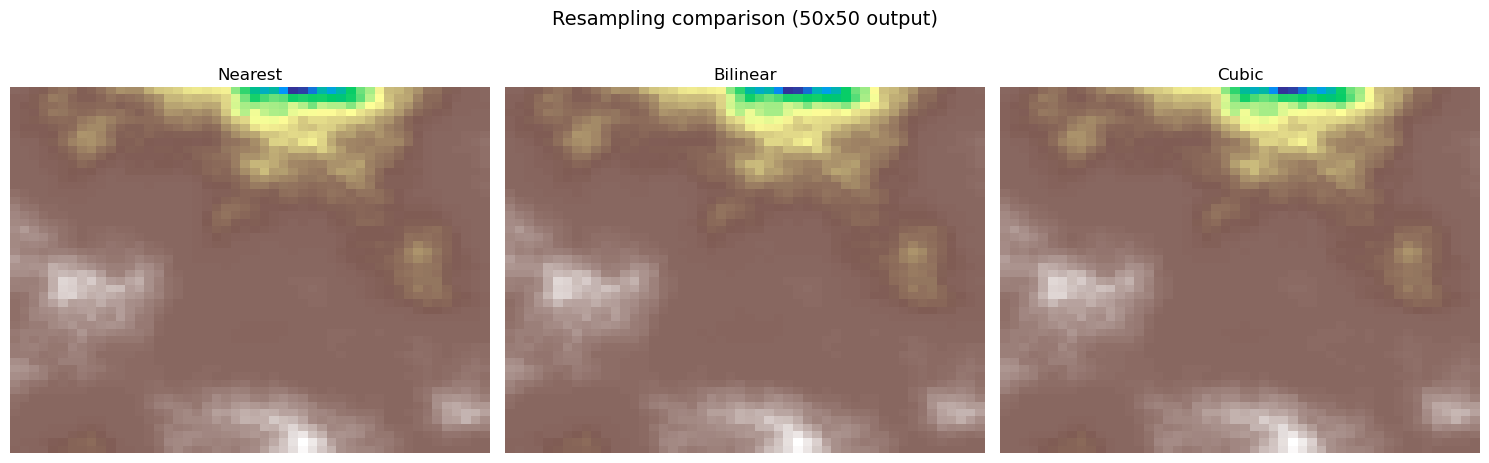

In [5]:
methods = ['nearest', 'bilinear', 'cubic']
results = {}
for method in methods:
    results[method] = reproject(terrain, 'EPSG:4326', width=50, height=50,
                                resampling=method)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, method in zip(axes, methods):
    results[method].plot.imshow(ax=ax, cmap='terrain', add_colorbar=False)
    ax.set_title(method.capitalize())
    ax.set_axis_off()

plt.suptitle('Resampling comparison (50x50 output)', fontsize=14, y=1.02)
plt.tight_layout()

Nearest shows blocky pixels. Bilinear smooths them out. Cubic is slightly smoother but at this scale the difference from bilinear is hard to see. For elevation data, bilinear is usually the right choice.

## Merge tiles

Real raster datasets often come as tiles that need to be stitched together. `merge` takes a list of DataArrays, reprojects them all to a common grid, and combines them into one output.

Here we split the terrain into a left tile and a right tile (with a 2-degree overlap zone in the middle), then merge them back.

Left tile:  x=[-10.0, 1.0], shape=(256, 141)
Right tile: x=[-1.0, 10.0], shape=(256, 141)
Overlap zone: x=[-1, 1]


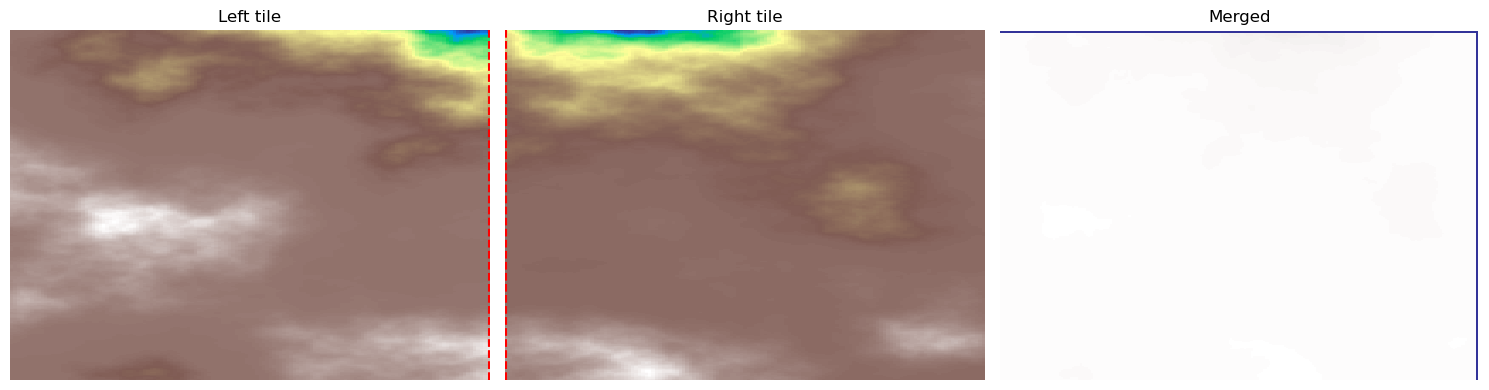

In [6]:
# Split into left and right tiles with 2-degree overlap
left_tile = terrain.sel(x=slice(-10, 1))    # -10 to 1
right_tile = terrain.sel(x=slice(-1, 10))   # -1 to 10

# Copy CRS attrs to tiles
left_tile.attrs['crs'] = 'EPSG:4326'
right_tile.attrs['crs'] = 'EPSG:4326'

print(f"Left tile:  x=[{float(left_tile.x.min()):.1f}, {float(left_tile.x.max()):.1f}], shape={left_tile.shape}")
print(f"Right tile: x=[{float(right_tile.x.min()):.1f}, {float(right_tile.x.max()):.1f}], shape={right_tile.shape}")
print(f"Overlap zone: x=[-1, 1]")

# Merge
merged = merge([left_tile, right_tile], resolution=0.08)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

left_tile.plot.imshow(ax=axes[0], cmap='terrain', add_colorbar=False)
axes[0].set_title('Left tile')
axes[0].axvline(1, color='red', linewidth=1.5, linestyle='--')

right_tile.plot.imshow(ax=axes[1], cmap='terrain', add_colorbar=False)
axes[1].set_title('Right tile')
axes[1].axvline(-1, color='red', linewidth=1.5, linestyle='--')

merged.plot.imshow(ax=axes[2], cmap='terrain', add_colorbar=False)
axes[2].set_title('Merged')

for ax in axes:
    ax.set_axis_off()

plt.tight_layout()

The merged raster covers the full extent of both tiles. The dashed red lines mark where each tile ends. In the overlap zone, the default `strategy='first'` keeps the values from the first raster in the list.

## Overlap strategies

When tiles overlap, five strategies control which value wins:

- **first**: keep the value from whichever raster appears first in the list
- **last**: keep the value from the last raster
- **mean**: average all valid values
- **max** / **min**: keep the largest or smallest value

If you're merging overlapping scenes from different dates or sensors, `mean` tends to reduce noise in the overlap zone. `first` is fastest since it stops checking once a pixel has a value.

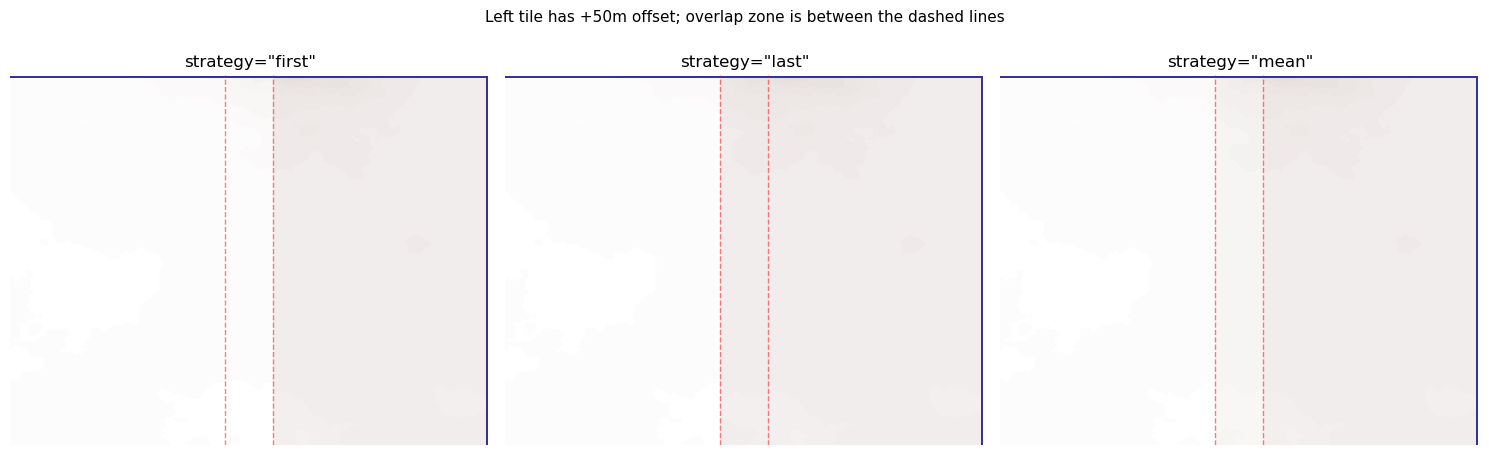

In [7]:
# Create tiles with different offsets to make overlap differences visible
left_offset = left_tile.copy()
left_offset.values = left_tile.values + 50   # shift up by 50m
left_offset.attrs['crs'] = 'EPSG:4326'

strategies = ['first', 'last', 'mean']
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, strat in zip(axes, strategies):
    result = merge([left_offset, right_tile], strategy=strat, resolution=0.08)
    result.plot.imshow(ax=ax, cmap='terrain', add_colorbar=False)
    ax.set_title(f'strategy="{strat}"')
    ax.axvline(-1, color='red', linewidth=1, linestyle='--', alpha=0.5)
    ax.axvline(1, color='red', linewidth=1, linestyle='--', alpha=0.5)
    ax.set_axis_off()

plt.suptitle('Left tile has +50m offset; overlap zone is between the dashed lines',
             fontsize=11, y=1.0)
plt.tight_layout()

Between the dashed lines you can see the difference: `first` shows the brighter (offset) left tile, `last` shows the darker right tile, and `mean` splits the difference. Outside the overlap zone, all three are identical.

## Cross-CRS merge

`merge` gets more useful when the input rasters are in different projections. Each one gets reprojected to the target CRS before combination, so you can feed in tiles from different sources directly.

Here we take the left tile in EPSG:4326 and reproject the right tile to EPSG:3857 first, then merge both into a single EPSG:4326 output.

Left tile CRS:  EPSG:4326 (degrees)
Right tile CRS: EPSG:3857 (meters)


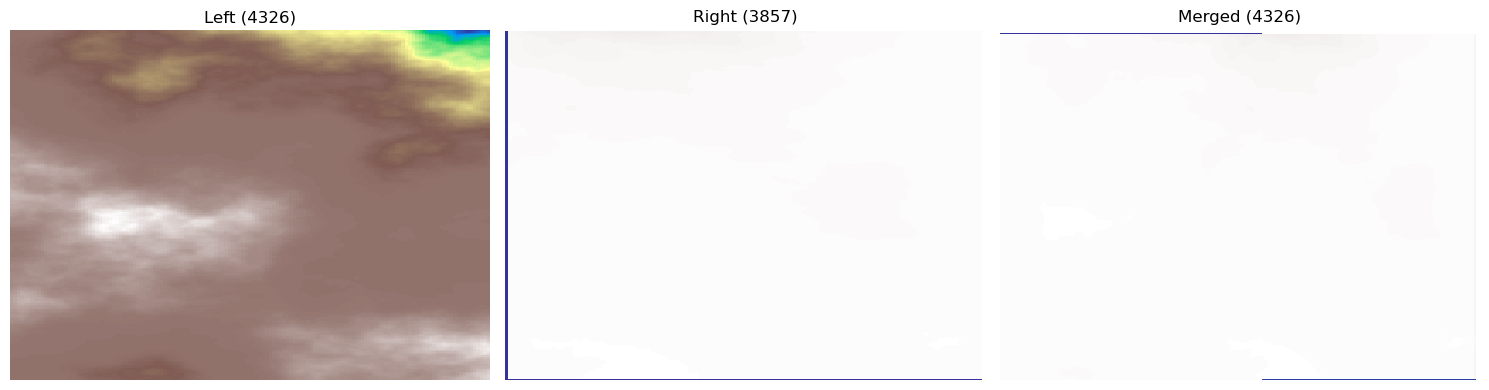

In [8]:
# Right tile reprojected to Web Mercator
right_tile_3857 = reproject(right_tile, 'EPSG:3857')

print(f"Left tile CRS:  EPSG:4326 (degrees)")
print(f"Right tile CRS: EPSG:3857 (meters)")

# Merge into EPSG:4326
cross_merged = merge([left_tile, right_tile_3857],
                     target_crs='EPSG:4326', resolution=0.08)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

left_tile.plot.imshow(ax=axes[0], cmap='terrain', add_colorbar=False)
axes[0].set_title('Left (4326)')
axes[0].set_axis_off()

right_tile_3857.plot.imshow(ax=axes[1], cmap='terrain', add_colorbar=False)
axes[1].set_title('Right (3857)')
axes[1].set_axis_off()

cross_merged.plot.imshow(ax=axes[2], cmap='terrain', add_colorbar=False)
axes[2].set_title('Merged (4326)')
axes[2].set_axis_off()

plt.tight_layout()

The middle panel has axes in meters (EPSG:3857) while the others are in degrees, but `merge` handled the reprojection internally. The output is a clean mosaic in the target CRS.

<div class="alert alert-block alert-info">
<b>Dask support.</b> Both <code>reproject</code> and <code>merge</code> work with dask-backed DataArrays. Each output chunk is computed lazily and independently, so you can reproject datasets that don't fit in memory. Pass <code>chunk_size=512</code> to control the output chunking.
</div>

In [9]:
# Generate preview image for the notebook index
import os
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

_nb_dir = os.path.dirname(os.path.abspath('__file__'))
# Handle both notebook and nbconvert execution
_img_dir = os.path.join(_nb_dir, 'examples', 'user_guide', 'images')
if not os.path.isdir(_img_dir):
    _img_dir = os.path.join(_nb_dir, 'images')
os.makedirs(_img_dir, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

terrain.plot.imshow(ax=axes[0], cmap='terrain', add_colorbar=False)
axes[0].set_title('Source (EPSG:4326)', fontsize=13)
axes[0].set_axis_off()

terrain_3857.plot.imshow(ax=axes[1], cmap='terrain', add_colorbar=False)
axes[1].set_title('Reprojected (EPSG:3857)', fontsize=13)
axes[1].set_axis_off()

cross_merged.plot.imshow(ax=axes[2], cmap='terrain', add_colorbar=False)
axes[2].set_title('Cross-CRS Merge', fontsize=13)
axes[2].set_axis_off()

plt.tight_layout()
fig.savefig(os.path.join(_img_dir, 'reproject_preview.png'),
            bbox_inches='tight', dpi=120)
plt.close(fig)
print("Preview saved.")

matplotlib.use('module://matplotlib_inline.backend_inline')

Preview saved.


### References

- [Map projection](https://en.wikipedia.org/wiki/Map_projection), Wikipedia
- [Web Mercator projection](https://en.wikipedia.org/wiki/Web_Mercator_projection), Wikipedia
- [EPSG:4326](https://epsg.io/4326) (WGS 84 geographic), epsg.io
- [EPSG:3857](https://epsg.io/3857) (Web Mercator), epsg.io
- [pyproj documentation](https://pyproj4.github.io/pyproj/stable/)